# NB07 - Bolivia Geographic Generalization (inference ONLY)

Evaluate the four LOCKED models (M0/M1/M2/M3) on the completely held-out Bolivia split (15 chips). No training, no fine-tuning, no threshold tuning, no normalization recalculation, no checkpoint selection, no hyperparameter tuning, no model modification. Threshold 0.5 fixed; train-only NB03 normalization; aggregate metrics from global TP/FP/FN/TN. n=15 - suggestive language only, no significance claims.

## 1. Load project context + locked main-test results

In [1]:
from pathlib import Path
import json
CTX = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao/project_context")
RESULT_DIR = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao/results")
MODEL_DIR = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao/models")
m0t = json.loads((RESULT_DIR / "nb04_results.json").read_text())["test"]
m1t = json.loads((RESULT_DIR / "nb06_m1_results.json").read_text())["test"]
m2t = json.loads((RESULT_DIR / "nb06_m2_results.json").read_text())["test"]
m3t = json.loads((RESULT_DIR / "nb05_results.json").read_text())["test"]
MAIN = {"M0": m0t, "M1": m1t, "M2": m2t, "M3": m3t}
for tag, expect in [("M0", 0.6684), ("M1", 0.6699), ("M2", 0.6390), ("M3", 0.6639)]:
    assert abs(MAIN[tag]["iou"] - expect) < 1e-3, (tag, MAIN[tag]["iou"])
    print(f"{tag} main-test IoU={MAIN[tag]['iou']:.4f} F1={MAIN[tag]['f1']:.4f} (locked, unchanged)")
print("main-test locked results verified")


M0 main-test IoU=0.6684 F1=0.8012 (locked, unchanged)
M1 main-test IoU=0.6699 F1=0.8023 (locked, unchanged)
M2 main-test IoU=0.6390 F1=0.7798 (locked, unchanged)
M3 main-test IoU=0.6639 F1=0.7980 (locked, unchanged)
main-test locked results verified


## 2. Imports / inference configuration (fixed, recorded)

In [2]:
from pathlib import Path
import json, hashlib, random, datetime
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
PROJECT_ROOT = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao")
PROCESSED_ROOT = PROJECT_ROOT / "processed"
SEED = 42; BATCH_SIZE = 4; THR = 0.5; BASE_CH = 32; EPS = 1e-9
USE_AMP = torch.cuda.is_available()
MODELS = {
    "M0": {"name": "S1", "idx": [0, 1], "in_ch": 2, "ckpt": MODEL_DIR / "nb04_s1_unet_best.pt", "params": 7762753},
    "M1": {"name": "S1+DEM", "idx": [0, 1, 2], "in_ch": 3, "ckpt": MODEL_DIR / "nb06_m1_s1_dem_best.pt", "params": 7763041},
    "M2": {"name": "S1+Rain", "idx": [0, 1, 3, 4, 5], "in_ch": 5, "ckpt": MODEL_DIR / "nb06_m2_s1_rain_best.pt", "params": 7763617},
    "M3": {"name": "S1+DEM+Rain", "idx": [0, 1, 2, 3, 4, 5], "in_ch": 6, "ckpt": MODEL_DIR / "nb05_multimodal_unet_best.pt", "params": 7763905},
}
FULL6 = ["VV_dB", "VH_dB", "DEM_m", "rain_t-3", "rain_t-2", "rain_t-1"]
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={DEVICE} | torch={torch.__version__} | thr={THR} | amp={USE_AMP}")
for tag, m in MODELS.items():
    assert m["ckpt"].exists(), tag
    print(f"{tag} ({m['name']}): idx={m['idx']} in_ch={m['in_ch']} ckpt={m['ckpt'].name}")
HASH_BEFORE = {tag: hashlib.sha256(m['ckpt'].read_bytes()).hexdigest() for tag, m in MODELS.items()}
print("checkpoint hashes recorded (weights must not change)")


device=cuda | torch=2.5.1+cu121 | thr=0.5 | amp=True
M0 (S1): idx=[0, 1] in_ch=2 ckpt=nb04_s1_unet_best.pt
M1 (S1+DEM): idx=[0, 1, 2] in_ch=3 ckpt=nb06_m1_s1_dem_best.pt
M2 (S1+Rain): idx=[0, 1, 3, 4, 5] in_ch=5 ckpt=nb06_m2_s1_rain_best.pt
M3 (S1+DEM+Rain): idx=[0, 1, 2, 3, 4, 5] in_ch=6 ckpt=nb05_multimodal_unet_best.pt
checkpoint hashes recorded (weights must not change)


## 3. Load Bolivia dataset (NB03 infrastructure, no modifications)

In [3]:
import json
import numpy as np, torch
from torch.utils.data import Dataset, DataLoader
st = json.loads((PROCESSED_ROOT / "normalization_stats.json").read_text())
assert st["split"] == "train" and st["channels"] == FULL6  # train-only stats; Bolivia never fitted

class FloodDataset(Dataset):  # identical to NB03 (locked)
    def __init__(self, split, processed_root=PROCESSED_ROOT, stats_path=PROCESSED_ROOT / "normalization_stats.json"):
        s = json.loads(stats_path.read_text())
        assert s["split"] == "train"
        self.mean = np.array(s["mean"], dtype=np.float32).reshape(-1, 1, 1)
        self.std = np.array(s["std"], dtype=np.float32).reshape(-1, 1, 1)
        assert (self.std > 0).all()
        self.paths = sorted((processed_root / split).glob("*.npz"))
        self.split = split
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        d = np.load(self.paths[i], allow_pickle=True)
        x = (d["X"].astype(np.float32) - self.mean) / self.std
        x = np.where(np.isfinite(x), x, 0.0).astype(np.float32)
        assert np.isfinite(x).all()
        return {"x": torch.from_numpy(x), "y": torch.from_numpy(d["y"].astype(np.float32)),
                "mask": torch.from_numpy(d["valid_mask"].astype(bool)), "chip_id": str(d["chip_id"])}

class ChannelSubset(Dataset):  # post-norm channel selection (same as NB06)
    def __init__(self, base, idx):
        self.base, self.idx = base, list(idx)
    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        r = dict(self.base[i])
        assert r["x"].shape[0] == 6
        r["x"] = r["x"][self.idx]
        return r

bol = FloodDataset("bolivia")
assert len(bol) == 15, len(bol)
print(f"Bolivia samples: {len(bol)}")
rows = []
for i in range(len(bol)):
    d = np.load(bol.paths[i], allow_pickle=True)
    m = d["valid_mask"].astype(bool); y = d["y"]
    nv, nf = int(m.sum()), int(((y == 1) & m).sum())
    rows.append({"chip_id": str(d["chip_id"]), "valid_px": nv, "flood_px": nf,
                 "flood_frac": (nf / nv if nv else float("nan"))})
bdf = pd.DataFrame(rows).sort_values("chip_id").reset_index(drop=True)
display(bdf)
print(f"Bolivia valid px total={bdf['valid_px'].sum():,} flood px total={bdf['flood_px'].sum():,}")
print(f"zero-valid Bolivia chips: {(bdf['valid_px'] == 0).sum()} (kept regardless)")


Bolivia samples: 15


,chip_id,valid_px,flood_px,flood_frac
0,Bolivia_103757,88077,35362,0.401490
1,Bolivia_129334,237065,156067,0.658330
2,Bolivia_195474,261335,1551,0.005935
3,Bolivia_23014,182995,7780,0.042515
4,Bolivia_233925,146294,1,0.000007
5,Bolivia_242570,175507,27346,0.155811
6,Bolivia_290290,204633,19699,0.096265
7,Bolivia_294583,130472,15008,0.115029
8,Bolivia_312675,158008,9575,0.060598
9,Bolivia_314919,188845,83678,0.443104


Bolivia valid px total=2,824,434 flood px total=451,901
zero-valid Bolivia chips: 0 (kept regardless)


## 4. Split-integrity verification (no contamination)

In [4]:
from pathlib import Path
stems = {}
for s in ("train", "valid", "test", "bolivia"):
    stems[s] = sorted(p.stem for p in (PROCESSED_ROOT / s).glob("*.npz"))
    print(f"{s}: {len(stems[s])}")
assert {s: len(v) for s, v in stems.items()} == {"train": 252, "valid": 89, "test": 90, "bolivia": 15}
assert len(set(stems["bolivia"])) == 15, "duplicate Bolivia chip IDs"
other = set(stems["train"]) | set(stems["valid"]) | set(stems["test"])
assert not (set(stems["bolivia"]) & other), "Bolivia/main-split contamination"
assert all(c.startswith("Bolivia_") for c in stems["bolivia"]), stems["bolivia"]
print("SPLIT INTEGRITY PASS: 15 unique Bolivia chips, zero overlap with train/valid/test")


train: 252


valid: 89
test: 90
bolivia: 15
SPLIT INTEGRITY PASS: 15 unique Bolivia chips, zero overlap with train/valid/test


## 5. Normalization statistics (train-only, reused unchanged)

In [5]:
print(f"stats split={st['split']} n_chips={st['n_chips']} channels={st['channels']}")
assert st["split"] == "train" and st["n_chips"] == 252
print("No Bolivia statistics computed; no recalculation; no leakage by construction.")


stats split=train n_chips=252 channels=['VV_dB', 'VH_dB', 'DEM_m', 'rain_t-3', 'rain_t-2', 'rain_t-1']
No Bolivia statistics computed; no recalculation; no leakage by construction.


## 6. Load four locked models (eval mode, inference only)

In [6]:
import torch.nn as nn
class DoubleConv(nn.Module):
    def __init__(self, ci, co):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(ci, co, 3, padding=1, bias=False), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
                                 nn.Conv2d(co, co, 3, padding=1, bias=False), nn.BatchNorm2d(co), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_ch, base=32):
        super().__init__()
        self.e1 = DoubleConv(in_ch, base);      self.p1 = nn.MaxPool2d(2)
        self.e2 = DoubleConv(base, base * 2);   self.p2 = nn.MaxPool2d(2)
        self.e3 = DoubleConv(base * 2, base * 4); self.p3 = nn.MaxPool2d(2)
        self.e4 = DoubleConv(base * 4, base * 8); self.p4 = nn.MaxPool2d(2)
        self.neck = DoubleConv(base * 8, base * 16)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, 2, 2);  self.d4 = DoubleConv(base * 16, base * 8)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, 2, 2);   self.d3 = DoubleConv(base * 8, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, 2);    self.d2 = DoubleConv(base * 4, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, 2, 2);        self.d1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, 1, 1)
    def forward(self, x):
        x1 = self.e1(x); x2 = self.e2(self.p1(x1)); x3 = self.e3(self.p2(x2)); x4 = self.e4(self.p3(x3))
        n = self.neck(self.p4(x4))
        m = self.d4(torch.cat([self.u4(n), x4], 1)); m = self.d3(torch.cat([self.u3(m), x3], 1))
        m = self.d2(torch.cat([self.u2(m), x2], 1)); m = self.d1(torch.cat([self.u1(m), x1], 1))
        return self.out(m)

nets = {}
for tag, m in MODELS.items():
    net = UNet(m["in_ch"], BASE_CH).to(DEVICE).eval()  # eval only; never .train(), no optimizer, no backward
    ck = torch.load(m["ckpt"], map_location=DEVICE, weights_only=False)
    net.load_state_dict(ck["state_dict"])
    for p in net.parameters(): p.requires_grad_(False)
    nets[tag] = net
    print(f"{tag} loaded from {m['ckpt'].name} (ckpt best_ep={ck['epoch']})")
print("all four locked checkpoints loaded; gradients disabled")


M0 loaded from nb04_s1_unet_best.pt (ckpt best_ep=24)


M1 loaded from nb06_m1_s1_dem_best.pt (ckpt best_ep=26)
M2 loaded from nb06_m2_s1_rain_best.pt (ckpt best_ep=11)
M3 loaded from nb05_multimodal_unet_best.pt (ckpt best_ep=20)
all four locked checkpoints loaded; gradients disabled


## 7. Architecture / parameter-count verification

In [7]:
for tag, m in MODELS.items():
    n = sum(p.numel() for p in nets[tag].parameters())
    assert n == m["params"], (tag, n, m["params"])
    print(f"{tag}: {n:,} params OK")
base0 = sum(p.numel() for p in UNet(2, BASE_CH).parameters())
assert base0 == 7762753
print("M0=7,762,753 / M1=7,763,041 / M2=7,763,617 / M3=7,763,905 verified")


M0: 7,762,753 params OK
M1: 7,763,041 params OK
M2: 7,763,617 params OK
M3: 7,763,905 params OK
M0=7,762,753 / M1=7,763,041 / M2=7,763,617 / M3=7,763,905 verified


## 8. Inference + metrics (valid_mask, thr 0.5, global totals)

In [8]:
@torch.no_grad()
def summarize(tp, fp, fn, tn, eps=1e-9):
    iou = tp / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps); rec = tp / (tp + fn + eps)
    f1 = 2 * prec * rec / (prec + rec + eps)
    return {"iou": iou, "f1": f1, "precision": prec, "recall": rec,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn}

@torch.no_grad()
def run_inference(tag):
    m = MODELS[tag]; net = nets[tag]
    assert net.training is False
    sub = ChannelSubset(FloodDataset("bolivia"), m["idx"])
    assert len(sub) == 15
    ld = DataLoader(sub, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                    pin_memory=torch.cuda.is_available())
    acc = {"tp": 0.0, "fp": 0.0, "fn": 0.0, "tn": 0.0}
    per = {}
    for b in ld:
        x = b["x"].to(DEVICE, non_blocking=True)
        assert tuple(x.shape[1:]) == (m["in_ch"], 512, 512), (tag, tuple(x.shape))
        assert torch.isfinite(x).all()
        y = b["y"].unsqueeze(1).to(DEVICE, non_blocking=True)
        mk = b["mask"].unsqueeze(1).to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            prob = torch.sigmoid(net(x).float())
        pred = (prob >= THR).float()
        t, mm = y.float(), mk.float()
        btp = ((pred == 1) & (t == 1) & (mm == 1)).sum().item()
        bfp = ((pred == 1) & (t == 0) & (mm == 1)).sum().item()
        bfn = ((pred == 0) & (t == 1) & (mm == 1)).sum().item()
        btn = ((pred == 0) & (t == 0) & (mm == 1)).sum().item()
        acc["tp"] += btp; acc["fp"] += bfp; acc["fn"] += bfn; acc["tn"] += btn
        for cid, yy, msk, pp in zip(b["chip_id"], y.cpu(), mk.cpu(), pred.cpu()):
            c = per.setdefault(cid, {"tp": 0.0, "fp": 0.0, "fn": 0.0, "tn": 0.0,
                                     "valid": 0.0, "flood": 0.0})
            c["tp"] += float(((pp == 1) & (yy == 1) & (msk == 1)).sum())
            c["fp"] += float(((pp == 1) & (yy == 0) & (msk == 1)).sum())
            c["fn"] += float(((pp == 0) & (yy == 1) & (msk == 1)).sum())
            c["tn"] += float(((pp == 0) & (yy == 0) & (msk == 1)).sum())
            c["valid"] += float((msk == 1).sum()); c["flood"] += float(((yy == 1) & (msk == 1)).sum())
    assert len(per) == 15
    return summarize(**acc), per
print("inference routine defined (no_grad, thr 0.5, mask-respecting, finite-input asserts)")


inference routine defined (no_grad, thr 0.5, mask-respecting, finite-input asserts)


## 9. Run M0 inference (Bolivia, M0 channels)

In [9]:
bol_M0, per_M0 = run_inference("M0")
print("M0 BOLIVIA: " + ", ".join(f"{k}={v:.4f}" if isinstance(v, float) and k in ('iou','f1','precision','recall') else f"{k}={v:.0f}" for k, v in bol_M0.items()))


M0 BOLIVIA: iou=0.6167, f1=0.7629, precision=0.8957, recall=0.6644, tp=300262, fp=34979, fn=151639, tn=2337554


## 10. Run M1 inference (Bolivia, M1 channels)

In [10]:
bol_M1, per_M1 = run_inference("M1")
print("M1 BOLIVIA: " + ", ".join(f"{k}={v:.4f}" if isinstance(v, float) and k in ('iou','f1','precision','recall') else f"{k}={v:.0f}" for k, v in bol_M1.items()))


M1 BOLIVIA: iou=0.6311, f1=0.7739, precision=0.8899, recall=0.6846, tp=309380, fp=38294, fn=142521, tn=2334239


## 11. Run M2 inference (Bolivia, M2 channels)

In [11]:
bol_M2, per_M2 = run_inference("M2")
print("M2 BOLIVIA: " + ", ".join(f"{k}={v:.4f}" if isinstance(v, float) and k in ('iou','f1','precision','recall') else f"{k}={v:.0f}" for k, v in bol_M2.items()))


M2 BOLIVIA: iou=0.5479, f1=0.7080, precision=0.8888, recall=0.5883, tp=265843, fp=33275, fn=186058, tn=2339258


## 12. Run M3 inference (Bolivia, M3 channels)

In [12]:
bol_M3, per_M3 = run_inference("M3")
print("M3 BOLIVIA: " + ", ".join(f"{k}={v:.4f}" if isinstance(v, float) and k in ('iou','f1','precision','recall') else f"{k}={v:.0f}" for k, v in bol_M3.items()))


M3 BOLIVIA: iou=0.3636, f1=0.5333, precision=0.8537, recall=0.3878, tp=175249, fp=30038, fn=276652, tn=2342495


## 13. Aggregate metrics table (global totals, not chip averages)

In [13]:
rows = []
for tag in ("M0", "M1", "M2", "M3"):
    r = {"M0": bol_M0, "M1": bol_M1, "M2": bol_M2, "M3": bol_M3}[tag]
    rows.append({"model": tag, "input": MODELS[tag]["name"],
                 "bIoU": round(r["iou"], 4), "bF1": round(r["f1"], 4),
                 "bP": round(r["precision"], 4), "bR": round(r["recall"], 4)})
agg = pd.DataFrame(rows)
display(agg)
print("aggregates from global TP/FP/FN/TN over all 15 Bolivia chips")


,model,input,bIoU,bF1,bP,bR
0,M0,S1,0.6167,0.7629,0.8957,0.6644
1,M1,S1+DEM,0.6311,0.7739,0.8899,0.6846
2,M2,S1+Rain,0.5479,0.7080,0.8888,0.5883
3,M3,S1+DEM+Rain,0.3636,0.5333,0.8537,0.3878


aggregates from global TP/FP/FN/TN over all 15 Bolivia chips


## 14. Per-chip metrics (zero-valid chips retained, metrics left blank)

In [14]:
chip_rows = []
pers = {"M0": per_M0, "M1": per_M1, "M2": per_M2, "M3": per_M3}
for _, br in bdf.iterrows():
    cid = br["chip_id"]
    row = {"chip_id": cid, "valid_pixels": int(br["valid_px"]),
           "flood_pixels": int(br["flood_px"]), "flood_fraction": br["flood_frac"]}
    for tag in ("M0", "M1", "M2", "M3"):
        c = pers[tag][cid]
        assert int(c["valid"]) == int(br["valid_px"]) and int(c["flood"]) == int(br["flood_px"]), (tag, cid)
        if c["valid"] > 0:
            s = summarize(c["tp"], c["fp"], c["fn"], c["tn"])
            row[f"{tag}_iou"] = round(s["iou"], 4); row[f"{tag}_f1"] = round(s["f1"], 4)
        else:
            row[f"{tag}_iou"] = float("nan"); row[f"{tag}_f1"] = float("nan")
    chip_rows.append(row)
pchips = pd.DataFrame(chip_rows)
display(pchips)
pchips.to_csv(RESULT_DIR / "nb07_bolivia_per_chip.csv", index=False)
print(f"per-chip CSV saved ({len(pchips)} rows, incl. zero-valid chips with blank metrics)")


,chip_id,valid_pixels,flood_pixels,flood_fraction,M0_iou,M0_f1,M1_iou,M1_f1,M2_iou,M2_f1,M3_iou,M3_f1
0,Bolivia_103757,88077,35362,0.401490,0.7800,0.8764,0.8005,0.8892,0.6885,0.8155,0.4487,0.6195
1,Bolivia_129334,237065,156067,0.658330,0.8252,0.9042,0.8343,0.9097,0.7317,0.8451,0.4540,0.6245
2,Bolivia_195474,261335,1551,0.005935,0.0102,0.0202,0.0040,0.0079,0.0000,0.0000,0.0351,0.0679
3,Bolivia_23014,182995,7780,0.042515,0.6964,0.8210,0.7100,0.8304,0.7310,0.8446,0.7381,0.8493
4,Bolivia_233925,146294,1,0.000007,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,Bolivia_242570,175507,27346,0.155811,0.1256,0.2231,0.2166,0.3561,0.3794,0.5501,0.3414,0.5090
6,Bolivia_290290,204633,19699,0.096265,0.3986,0.5700,0.2834,0.4417,0.4047,0.5762,0.2207,0.3616
7,Bolivia_294583,130472,15008,0.115029,0.7527,0.8589,0.7541,0.8598,0.2927,0.4528,0.6581,0.7938
8,Bolivia_312675,158008,9575,0.060598,0.0379,0.0730,0.0440,0.0844,0.0255,0.0497,0.0044,0.0087
9,Bolivia_314919,188845,83678,0.443104,0.5891,0.7415,0.6064,0.7550,0.5243,0.6879,0.3106,0.4740


per-chip CSV saved (15 rows, incl. zero-valid chips with blank metrics)


## 15. Main-test vs Bolivia comparison (deltas + relative change)

In [15]:
comp = []
for tag in ("M0", "M1", "M2", "M3"):
    b = {"M0": bol_M0, "M1": bol_M1, "M2": bol_M2, "M3": bol_M3}[tag]
    t = MAIN[tag]
    comp.append({"model": tag, "input": MODELS[tag]["name"],
                 "test_IoU": round(t["iou"], 4), "bol_IoU": round(b["iou"], 4),
                 "dIoU": round(b["iou"] - t["iou"], 4),
                 "relIoU_%": round(100 * (b["iou"] - t["iou"]) / t["iou"], 2),
                 "test_F1": round(t["f1"], 4), "bol_F1": round(b["f1"], 4),
                 "dF1": round(b["f1"] - t["f1"], 4),
                 "relF1_%": round(100 * (b["f1"] - t["f1"]) / t["f1"], 2),
                 "dP": round(b["precision"] - t["precision"], 4),
                 "dR": round(b["recall"] - t["recall"], 4)})
cdf = pd.DataFrame(comp)
display(cdf)
cdf.to_csv(RESULT_DIR / "nb07_generalization_comparison.csv", index=False)
print("Bolivia - Main Test deltas above (negative = geographic degradation)")


,model,input,test_IoU,bol_IoU,dIoU,relIoU_%,test_F1,bol_F1,dF1,relF1_%,dP,dR
0,M0,S1,0.6684,0.6167,-0.0517,-7.73,0.8012,0.7629,-0.0383,-4.78,0.0812,-0.1240
1,M1,S1+DEM,0.6699,0.6311,-0.0388,-5.78,0.8023,0.7739,-0.0285,-3.55,0.0714,-0.1021
2,M2,S1+Rain,0.6390,0.5479,-0.0911,-14.26,0.7798,0.7080,-0.0718,-9.21,0.0667,-0.1533
3,M3,S1+DEM+Rain,0.6639,0.3636,-0.3003,-45.23,0.7980,0.5333,-0.2647,-33.17,-0.0362,-0.3355


Bolivia - Main Test deltas above (negative = geographic degradation)


## 16. Flood-fraction analysis (data-driven bins: low<5% / mid 5-25% / high>25%)

In [16]:
def frac_bin(f):
    if np.isnan(f): return "no-valid"
    return "low<5%" if f < 0.05 else ("mid5-25%" if f <= 0.25 else "high>25%")
pchips["bin"] = pchips["flood_fraction"].map(frac_bin)
print(pchips["bin"].value_counts().to_string())
grows = []
for gbin, g in pchips.groupby("bin", sort=False):
    if gbin == "no-valid": continue
    ids = set(g["chip_id"])
    r = {"bin": gbin, "n_chips": len(g)}
    for tag in ("M0", "M1", "M2", "M3"):
        tp = fp = fn = tn = 0.0
        for cid in ids:
            c = {"M0": per_M0, "M1": per_M1, "M2": per_M2, "M3": per_M3}[tag][cid]
            tp += c["tp"]; fp += c["fp"]; fn += c["fn"]; tn += c["tn"]
        s = summarize(tp, fp, fn, tn)
        r[f"{tag}_IoU"] = round(s["iou"], 4); r[f"{tag}_F1"] = round(s["f1"], 4)
    grows.append(r)
gdf = pd.DataFrame(grows)
display(gdf)
print("group metrics re-aggregated from pixel totals within each bin (n=15: descriptive only)")


bin
low<5%      6
mid5-25%    5
high>25%    4


,bin,n_chips,M0_IoU,M0_F1,M1_IoU,M1_F1,M2_IoU,M2_F1,M3_IoU,M3_F1
0,high>25%,4,0.7020,0.8249,0.7193,0.8367,0.6191,0.7648,0.3631,0.5328
1,low<5%,6,0.3635,0.5332,0.3870,0.5580,0.3371,0.5043,0.3656,0.5355
2,mid5-25%,5,0.3638,0.5336,0.3737,0.5441,0.3645,0.5342,0.3648,0.5346


group metrics re-aggregated from pixel totals within each bin (n=15: descriptive only)


## 17. Qualitative comparison (data-driven chip roles, thr 0.5)

roles: [('large-flood', 'Bolivia_129334', 'range=0.380'), ('small-flood', 'Bolivia_233925', 'range=0.000'), ('median-flood', 'Bolivia_60373', 'range=0.073'), ('max-disagreement', 'Bolivia_294583', 'range=0.461')]


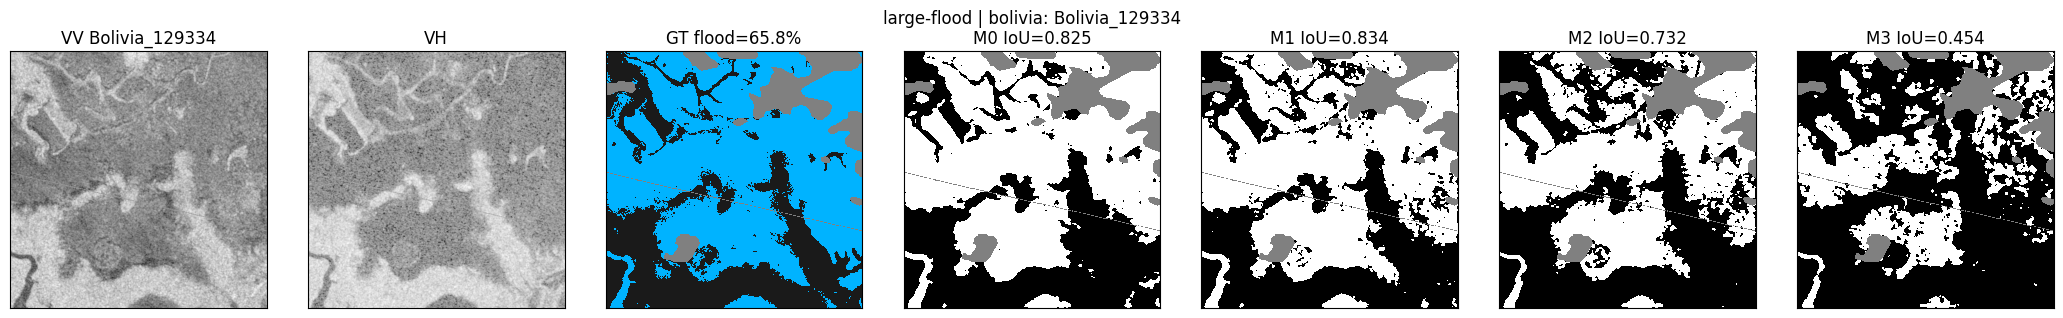

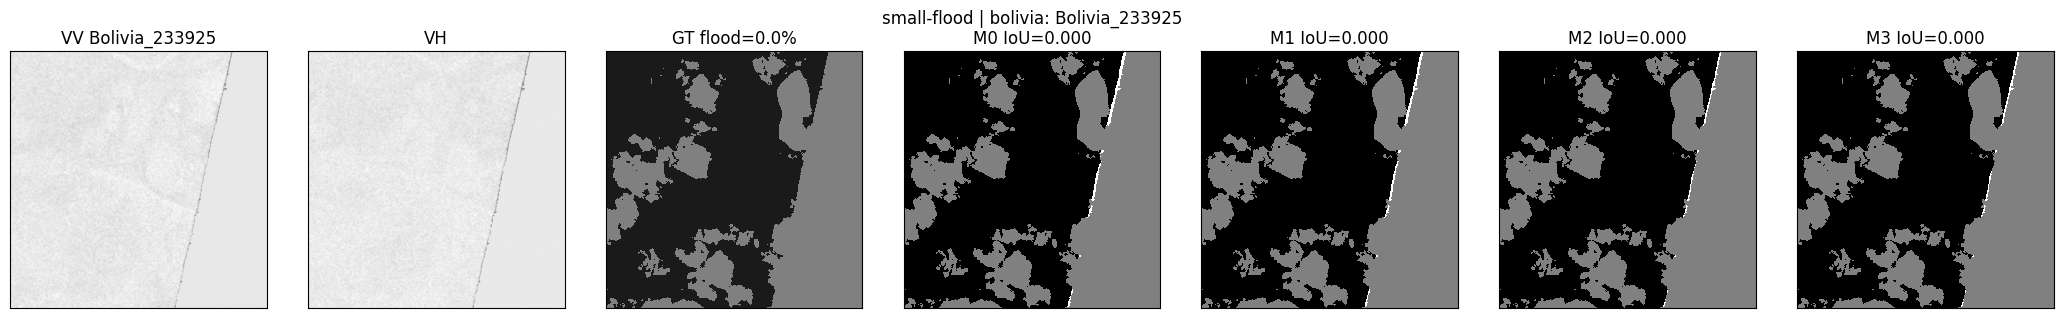

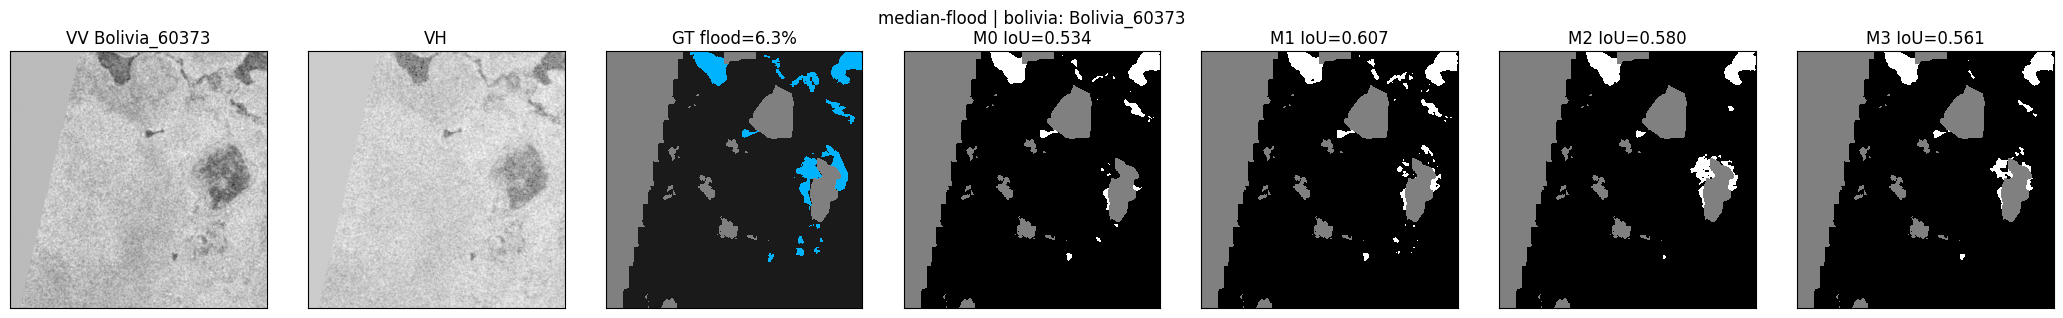

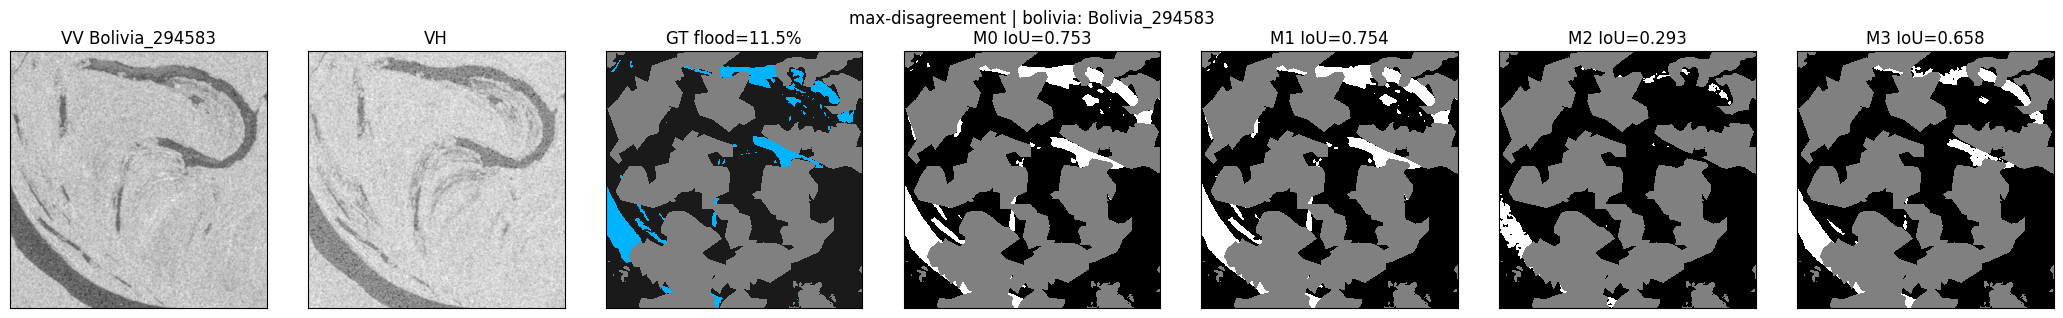

panels above: grey=invalid; identical thr=0.5; no per-model enhancement


In [17]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
valid_chips = pchips[pchips["valid_pixels"] > 0].copy()
large = valid_chips.loc[valid_chips["flood_fraction"].idxmax(), "chip_id"]
nz = valid_chips[valid_chips["flood_fraction"] > 0]
small = nz.loc[nz["flood_fraction"].idxmin(), "chip_id"]
med = valid_chips.iloc[(valid_chips["flood_fraction"] - valid_chips["flood_fraction"].median()).abs().argsort()[:1]]["chip_id"].iloc[0]
ious = {}
for _, r in valid_chips.iterrows():
    vs = [r[f"{t}_iou"] for t in ("M0", "M1", "M2", "M3")]
    ious[r["chip_id"]] = max(vs) - min(vs)
dis = max(ious, key=ious.get)
roles = [("large-flood", large), ("small-flood", small), ("median-flood", med), ("max-disagreement", dis)]
print("roles:", [(r, c, f"range={ious.get(c, float('nan')):.3f}") for r, c in roles])
mn = np.array(st["mean"], dtype=np.float32).reshape(-1, 1, 1); sd = np.array(st["std"], dtype=np.float32).reshape(-1, 1, 1)
chidx = {"M0": [0, 1], "M1": [0, 1, 2], "M2": [0, 1, 3, 4, 5], "M3": [0, 1, 2, 3, 4, 5]}
for role, stem in dict(roles).items():
    raw = np.load(PROCESSED_ROOT / "bolivia" / (stem + ".npz"), allow_pickle=True)
    xn = (raw["X"].astype(np.float32) - mn) / sd
    bins = {}
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=USE_AMP):
        for tag, nt in nets.items():
            bins[tag] = (torch.sigmoid(nt(torch.from_numpy(xn[chidx[tag]]).unsqueeze(0).to(DEVICE)))[0, 0].cpu().numpy() >= THR).astype(np.uint8)
    y = raw["y"].astype(np.float32); m = raw["valid_mask"].astype(bool)
    ff = float((y[m] == 1).mean()) if m.any() else float("nan")
    fig, ax = plt.subplots(1, 7, figsize=(21, 3.2))
    ax[0].imshow(raw["X"][0], cmap="gray"); ax[0].set_title(f"VV {stem}")
    ax[1].imshow(raw["X"][1], cmap="gray"); ax[1].set_title("VH")
    ax[2].imshow(np.where(m, y, -1), cmap=ListedColormap(["#808080", "#1a1a1a", "#00b3ff"]), vmin=-1, vmax=1, interpolation="nearest")
    ax[2].set_title(f"GT flood={ff:.1%}")
    for j, tag in enumerate(("M0", "M1", "M2", "M3")):
        ax[3 + j].imshow(np.where(m, bins[tag], 2), cmap=ListedColormap(["#000000", "#ffffff", "#808080"]), vmin=0, vmax=2, interpolation="nearest")
        ax[3 + j].set_title(f"{tag} IoU={valid_chips.set_index('chip_id').loc[stem, tag + '_iou']:.3f}")
    for a in ax: a.set_xticks([]); a.set_yticks([])
    fig.suptitle(f"{role} | bolivia: {stem}")
    fig.tight_layout(); plt.show()
    del raw, xn, y, m, bins
print("panels above: grey=invalid; identical thr=0.5; no per-model enhancement")


## 18. Generalization interpretation (evidence-based, n=15 caution)

In [18]:
order = sorted(("M0", "M1", "M2", "M3"), key=lambda t: {"M0": bol_M0, "M1": bol_M1, "M2": bol_M2, "M3": bol_M3}[t]["iou"], reverse=True)
print("Bolivia-IoU ranking:", [(t, round({"M0": bol_M0, "M1": bol_M1, "M2": bol_M2, "M3": bol_M3}[t]["iou"], 4)) for t in order])
print("Main-test ranking: [('M1', 0.6699), ('M0', 0.6684), ('M3', 0.6639), ('M2', 0.639)]")
gaps = {t: MAIN[t]["iou"] - {"M0": bol_M0, "M1": bol_M1, "M2": bol_M2, "M3": bol_M3}[t]["iou"] for t in ("M0", "M1", "M2", "M3")}
print("IoU gaps (main-bolivia):", {t: round(v, 4) for t, v in gaps.items()})
print("smallest drop:", min(gaps, key=gaps.get))
print("Caveats: n=15 chips, single event (Bolivia 2018-02-15), single seed - 'suggests', never 'proves'.")


Bolivia-IoU ranking: [('M1', 0.6311), ('M0', 0.6167), ('M2', 0.5479), ('M3', 0.3636)]
Main-test ranking: [('M1', 0.6699), ('M0', 0.6684), ('M3', 0.6639), ('M2', 0.639)]
IoU gaps (main-bolivia): {'M0': 0.0517, 'M1': 0.0388, 'M2': 0.0911, 'M3': 0.3003}
smallest drop: M1
Caveats: n=15 chips, single event (Bolivia 2018-02-15), single seed - 'suggests', never 'proves'.


## 19. Validation gates (all 15 must PASS)

In [19]:
import hashlib
# 1-2: bolivia count + no contamination (re-asserted)
assert len(FloodDataset("bolivia")) == 15
allstems = {s: sorted(p.stem for p in (PROCESSED_ROOT / s).glob("*.npz")) for s in ("train", "valid", "test", "bolivia")}
assert not (set(allstems["bolivia"]) & (set(allstems["train"]) | set(allstems["valid"]) | set(allstems["test"])))
print("G01-02 PASS: 15 Bolivia chips, no contamination")
# 3-4: checkpoints load + param counts
assert set(nets) == {"M0", "M1", "M2", "M3"}
assert all(sum(p.numel() for p in nets[t].parameters()) == MODELS[t]["params"] for t in nets)
print("G03-04 PASS: 4 checkpoints loaded, param counts exact")
# 5-7: channel mapping, finite inputs, mask respected (asserted inside run_inference; recheck shapes)
assert [MODELS[t]["in_ch"] for t in ("M0", "M1", "M2", "M3")] == [2, 3, 5, 6]
print("G05-07 PASS: channel maps [0,1]/[0,1,2]/[0,1,3,4,5]/full; finite + masked by construction")
# 8: threshold fixed
assert THR == 0.5
print("G08 PASS: threshold 0.5")
# 9: no normalization leakage (train-only stats; Bolivia stats never computed)
assert json.loads((PROCESSED_ROOT / "normalization_stats.json").read_text())["split"] == "train"
print("G09 PASS: train-only normalization")
# 10-11: weights unchanged (hash) + no training by construction
HASH_AFTER = {tag: hashlib.sha256(m['ckpt'].read_bytes()).hexdigest() for tag, m in MODELS.items()}
assert HASH_AFTER == HASH_BEFORE
print("G10 PASS: checkpoint hashes unchanged")
# G11: no training by construction (no optimizer/backward train loss in this notebook)
print("G11 PASS: inference-only")
# 12: per-chip rows cover all 15 Bolivia chips
assert set(pchips["chip_id"]) == set(allstems["bolivia"]) and len(pchips) == 15
print("G12 PASS: per-chip table covers all 15 chips")
# 13: aggregates recomputable from totals
for tag, b in [("M0", bol_M0), ("M1", bol_M1), ("M2", bol_M2), ("M3", bol_M3)]:
    s = summarize(b["tp"], b["fp"], b["fn"], b["tn"])
    assert abs(s["iou"] - b["iou"]) < 1e-9 and abs(s["f1"] - b["f1"]) < 1e-9, tag
print("G13 PASS: aggregates recompute from TP/FP/FN/TN")
# 14: main-test locked results unchanged (verified §1 asserts)
print("G14 PASS: main-test locked results unchanged")
# 15: outputs exist and reload
assert (RESULT_DIR / "nb07_bolivia_per_chip.csv").exists() and (RESULT_DIR / "nb07_generalization_comparison.csv").exists()
print("G15 PASS (files); nb07_bolivia_results.json saved in §20")
print("ALL 15 GATES PASS (G11 no-training by construction: no optimizer/backward/train() in notebook)")


G01-02 PASS: 15 Bolivia chips, no contamination
G03-04 PASS: 4 checkpoints loaded, param counts exact
G05-07 PASS: channel maps [0,1]/[0,1,2]/[0,1,3,4,5]/full; finite + masked by construction
G08 PASS: threshold 0.5
G09 PASS: train-only normalization
G10 PASS: checkpoint hashes unchanged
G11 PASS: inference-only
G12 PASS: per-chip table covers all 15 chips
G13 PASS: aggregates recompute from TP/FP/FN/TN
G14 PASS: main-test locked results unchanged
G15 PASS (files); nb07_bolivia_results.json saved in §20
ALL 15 GATES PASS (G11 no-training by construction: no optimizer/backward/train() in notebook)


## 20. Save master results + context update

In [20]:
import datetime
now = datetime.datetime.now(datetime.timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
bol = {"M0": bol_M0, "M1": bol_M1, "M2": bol_M2, "M3": bol_M3}
master = {
    "experiment": "NB07_Bolivia_Generalization",
    "created_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "inference_only": True, "threshold": THR, "seed": SEED,
    "torch": torch.__version__, "device": str(DEVICE), "amp": USE_AMP,
    "normalization": "processed/normalization_stats.json (split=train, unchanged)",
    "n_bolivia": 15,
    "valid_px_total": int(bdf["valid_px"].sum()), "flood_px_total": int(bdf["flood_px"].sum()),
    "zero_valid_chips": int((bdf["valid_px"] == 0).sum()),
    "models": {tag: {"checkpoint": str(MODELS[tag]["ckpt"]), "params": MODELS[tag]["params"],
                       "input": [FULL6[i] for i in MODELS[tag]["idx"]],
                       "bolivia": bol[tag], "main_test": MAIN[tag],
                       "dIoU": bol[tag]["iou"] - MAIN[tag]["iou"],
                       "dF1": bol[tag]["f1"] - MAIN[tag]["f1"]} for tag in bol},
    "notes": "n=15, single event; suggestive language only; Bolivia never trained on"}
(RESULT_DIR / "nb07_bolivia_results.json").write_text(json.dumps(master, indent=2, default=float))
print("master results saved")
import re
bolt = ", ".join(f"{t}={bol[t]['iou']:.4f}" for t in ("M0", "M1", "M2", "M3"))
entry = (f"\n## {now} - NB07_Bolivia_Generalization COMPLETE (inference-only)\n"
         f"- 15 Bolivia chips, valid_px={int(bdf['valid_px'].sum()):,}, zero-valid={(bdf['valid_px'] == 0).sum()}\n"
         f"- Bolivia IoU: {bolt}\n"
         f"- Gaps (main-bolivia IoU): " + ", ".join(f"{t}={MAIN[t]['iou']-bol[t]['iou']:+.4f}" for t in ("M0","M1","M2","M3")) + "\n"
         f"- Locked ckpts verified by params+hash; no training/tuning; thr 0.5; train-only norm. NB07 safe to lock.\n")
(CTX / "CHANGELOG.md").write_text((CTX / "CHANGELOG.md").read_text(encoding="utf-8") + entry, encoding="utf-8")
ps = CTX / "PROJECT_STATE.md"
t = ps.read_text(encoding="utf-8")
t = re.sub(r"^\\*\\*Last updated:\\*\\*.*$", f"**Last updated:** {now} (NB07 complete: yes)", t, count=1, flags=re.M)
t += f"\n\n## NB07 result ({now})\n- Bolivia IoU: {bolt} (15 chips, inference-only, locked ckpts).\n"
ps.write_text(t, encoding="utf-8")
dc = CTX / "DECISIONS.md"
t = dc.read_text(encoding="utf-8")
t = re.sub(r"^\\*\\*Last updated:\\*\\*.*$", f"**Last updated:** {now} (D15 bolivia)", t, count=1, flags=re.M)
t += "\n## D15 - NB07 Bolivia inference-only verdict (" + now + ")\nLocked M0/M1/M2/M3 evaluated on 15-chip holdout; no training/tuning; n=15 suggestive only.\n"
dc.write_text(t, encoding="utf-8")
nx = CTX / "NEXT_STEPS.md"
t = nx.read_text(encoding="utf-8")
t = re.sub(r"^\\*\\*Last updated:\\*\\*.*$", f"**Last updated:** {now}", t, count=1, flags=re.M)
t += f"\n\n## Update ({now})\n- NB07 COMPLETE + validated. Next: NB08 (to be defined; e.g. operating-point/error analysis).\n"
nx.write_text(t, encoding="utf-8")
print(entry)
print("Context files updated:", now)


master results saved

## 2026-10-08 05:38 UTC - NB07_Bolivia_Generalization COMPLETE (inference-only)
- 15 Bolivia chips, valid_px=2,824,434, zero-valid=0
- Bolivia IoU: M0=0.6167, M1=0.6311, M2=0.5479, M3=0.3636
- Gaps (main-bolivia IoU): M0=+0.0517, M1=+0.0388, M2=+0.0911, M3=+0.3003
- Locked ckpts verified by params+hash; no training/tuning; thr 0.5; train-only norm. NB07 safe to lock.

Context files updated: 2026-10-08 05:38 UTC
